In [106]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv


In [107]:
load_dotenv()

True

In [108]:
llm=ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview"
)

In [109]:
class SentimentSchema(BaseModel):
    sentiment:Literal["positive","negative"]=Field(description='sentiment of ths review')

In [110]:
structured_model=llm.with_structured_output(SentimentSchema)

In [111]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal["positive","negative"]
    diagnosis:dict
    response:str

In [112]:
def findSentiment(state:ReviewState):
    prompt=f"""what is the sentiment of the following review \n {state["review"]}"""
    sentiment=structured_model.invoke(prompt).sentiment
    return {'sentiment':sentiment}

In [113]:
def check_sentiment(state: ReviewState):
    if state["sentiment"] == "positive":
        return "positive_response"
    else:
        return "negative_response"

In [114]:
def positive_response(state: ReviewState):

    prompt = f"""
    You are a friendly and helpful customer-support assistant.

    The user gave this positive feedback:
    "{state['review']}"

    Write a short, warm thank-you message.
    Appreciate the user's feedback and encourage them to share
    more feedback in the future.

    Do not mention that you are an AI.
    """

    response = llm.invoke(prompt)

    return {
        "response": response.content
    }


def negative_response(state: ReviewState):

    prompt = f"""
    You are a professional and empathetic customer-support assistant.

    The user gave this negative feedback:
    "{state['review']}"

    Write a short, sincere response that:
    - Acknowledges the user's frustration.
    - Apologizes for the poor experience.
    - Assures the user that their feedback is taken seriously.
    - Says that the feedback will be used to improve the experience.

    Do not make unrealistic promises.
    Do not mention that you are an AI.
    """

    response = llm.invoke(prompt)

    return {
        "response": response.content
    }

In [115]:
def dignosis(state: ReviewState):
    return "dignosis"

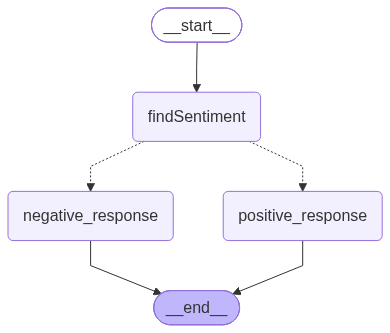

In [116]:
graph=StateGraph(ReviewState)
graph.add_edge(START,'findSentiment')
graph.add_node('findSentiment',findSentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('negative_response',negative_response)
# graph.add_node('dignosis',dignosis)
graph.add_conditional_edges(
    "findSentiment",
    check_sentiment,
    {
        "positive_response": "positive_response",
        "negative_response": "negative_response"
    }
)
# graph.add_edge('negative_response','dignosis')
graph.add_edge('positive_response',END)
graph.add_edge('negative_response',END)
# graph.add_edge('dignosis',END)
workflow=graph.compile()
workflow

In [117]:
initial_state={
    'review':'the product is very bad'
}

final_state=workflow.invoke(initial_state)
print(final_state['response'][0]['text'])

I am very sorry to hear that you’ve had such a disappointing experience with our product. We take feedback like yours seriously, as it helps us understand where we need to improve. Please be assured that your comments will be shared with our team to help us provide a better experience in the future.
